# QAOA in Finance: From S&P Data to Quantum Circuits

**Based on:** *QAOA in Finance: A Research-Level Treatment — From S&P Data to Spin Glasses and Quantum Circuits*  
Morten Hjorth-Jensen, Spring 2026

---

This notebook develops the full pipeline from financial portfolio optimisation to a quantum
circuit simulation, step by step.  Every equation drives the corresponding code cell immediately
below it, and two real-world datasets are included for hands-on exploration.

**Pipeline overview:**

$$
\text{Financial Data}
\;\rightarrow\; (\mu,\Sigma)
\;\rightarrow\; \text{QUBO}
\;\rightarrow\; \text{Ising Hamiltonian}
\;\rightarrow\; \text{Pauli operators}
\;\rightarrow\; \text{QAOA}
$$

| Section | Topic |
|:--------|:------|
| 1 | Mean-variance portfolio optimisation |
| 2 | QUBO formulation |
| 3 | Ising Hamiltonian mapping |
| 4 | Quantum Pauli operators |
| 5 | QAOA algorithm and circuit |
| 6 | Datasets: synthetic and real S&P 500 |
| 7 | Full simulation and results |
| 8 | Statistical physics connection |


## Imports and Setup

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.optimize import minimize
from itertools import product

np.random.seed(42)
print('NumPy', np.__version__)


NumPy 1.22.3


## Section 1 — Mean-Variance Portfolio Optimisation

### 1.1  The objective

We have $n$ assets. Asset $i$ has expected daily return $\mu_i$ and the $n\times n$ matrix
$\Sigma$ is the **return covariance matrix**. The portfolio allocation is encoded by a binary
vector $x \in \{0,1\}^n$ where $x_i = 1$ means asset $i$ is selected.

The **mean-variance objective** (Markowitz 1952) balances return against risk:

$$
\min_{x} \;\Bigl(-\mu^\top x + \lambda\, x^\top \Sigma\, x\Bigr),
$$

where $\lambda > 0$ is the **risk-aversion parameter**.

- The term $-\mu^\top x$ maximises expected return.
- The term $\lambda\, x^\top \Sigma\, x$ penalises portfolio variance (risk).

### 1.2  Budget constraint

We impose a **fixed-budget constraint**: exactly $K$ assets must be selected:

$$
\sum_{i=1}^n x_i = K.
$$

This hard constraint is relaxed into a **quadratic penalty**:

$$
C(x) = -\mu^\top x + \lambda\, x^\top \Sigma\, x
+ A\!\left(\sum_{i=1}^n x_i - K\right)^2,
$$

where $A > 0$ is the penalty coefficient, chosen large enough that the minimum of $C(x)$
always satisfies the budget constraint.

### 1.3  Return and covariance from price data

Daily log-returns are computed from closing prices $P_i(t)$:

$$
r_i(t) = \frac{P_i(t+1) - P_i(t)}{P_i(t)} \approx \ln\frac{P_i(t+1)}{P_i(t)}.
$$

Then:

$$
\mu_i = \langle r_i \rangle_t, \qquad
\Sigma_{ij} = \langle r_i r_j \rangle - \langle r_i \rangle\langle r_j \rangle.
$$


## Section 2 — QUBO Formulation

### 2.1  Quadratic Unconstrained Binary Optimisation (QUBO)

A **QUBO** problem has the form

$$
\min_{x \in \{0,1\}^n} C(x) = \sum_{i} Q_{ii}\, x_i + \sum_{i < j} Q_{ij}\, x_i x_j,
$$

where for binary variables $x_i^2 = x_i$, so diagonal entries absorb linear terms.

### 2.2  Deriving Q from the finance problem

Expanding the finance cost (and using $x_i^2 = x_i$):

$$
C(x) = \sum_i \underbrace{\bigl[-\mu_i + \lambda\Sigma_{ii} + A(1-2K)\bigr]}_{Q_{ii}}\, x_i
+ \sum_{i<j} \underbrace{\bigl[2\lambda\Sigma_{ij} + 2A\bigr]}_{Q_{ij}}\, x_i x_j
+ \underbrace{AK^2}_{\text{const}},
$$

so the QUBO coefficients are:

$$
\boxed{
Q_{ii} = -\mu_i + \lambda\Sigma_{ii} + A(1-2K),
\qquad
Q_{ij} = 2\lambda\Sigma_{ij} + 2A \quad (i < j).
}
$$

The constant $AK^2$ can be dropped from the optimisation (it shifts all costs equally).

### 2.3  Code: building the QUBO matrix


In [2]:
def build_qubo(mu, Sigma, lam, A, K):
    """
    Build the QUBO coefficient matrix for mean-variance portfolio optimisation.

    The cost function is
        C(x) = sum_i Q[i,i]*x_i + sum_{i<j} Q[i,j]*x_i*x_j + A*K^2

    where:
        Q[i,i] = -mu_i + lam*Sigma[i,i] + A*(1 - 2*K)   (diagonal / linear)
        Q[i,j] = 2*lam*Sigma[i,j] + 2*A                  (off-diagonal / quadratic)

    Parameters
    ----------
    mu    : (n,) expected daily returns
    Sigma : (n,n) return covariance
    lam   : float  risk-aversion coefficient
    A     : float  budget-constraint penalty coefficient
    K     : int    number of assets to select

    Returns
    -------
    Q      : (n,n) symmetric QUBO matrix (upper-triangular form: Q[i,j]=0 for i>j)
    offset : float  constant AK^2 (add back when evaluating absolute costs)
    """
    n = len(mu)
    Q = np.zeros((n, n))
    for i in range(n):
        Q[i, i] = -mu[i] + lam*Sigma[i, i] + A*(1 - 2*K)  # linear term
        for j in range(i+1, n):
            Q[i, j] = 2*lam*Sigma[i, j] + 2*A              # quadratic term
    offset = A * K**2
    return Q, offset


def eval_qubo(x, Q, offset):
    """
    Evaluate C(x) = sum_i Q[i,i]*x_i + sum_{i<j} Q[i,j]*x_i*x_j + offset.

    Parameters
    ----------
    x      : (n,) binary vector
    Q      : (n,n) QUBO matrix from build_qubo
    offset : float from build_qubo
    """
    n = len(x)
    val = offset + np.dot(np.diag(Q), x)
    for i in range(n):
        for j in range(i+1, n):
            val += Q[i, j] * x[i] * x[j]
    return val


## Section 3 — Ising Hamiltonian Mapping

### 3.1  Binary to spin substitution

We map $x_i \in \{0,1\}$ to spin variables $z_i \in \{-1, +1\}$ via

$$
x_i = \frac{1 - z_i}{2}.
$$

Substituting into $C(x)$ and collecting terms by degree gives an **Ising Hamiltonian**:

$$
H(z) = \sum_i h_i\, z_i + \sum_{i<j} J_{ij}\, z_i z_j,
$$

where the constant is absorbed into a shift. The coefficients are:

$$
\boxed{
h_i = -\frac{Q_{ii}}{2} - \frac{1}{4}\sum_{j \neq i} Q_{ij},
\qquad
J_{ij} = \frac{Q_{ij}}{4} \quad (i < j),
}
$$

and the total additive constant is

$$
c = \text{offset} + \frac{1}{2}\sum_i Q_{ii} + \frac{1}{4}\sum_{i<j} Q_{ij},
$$

so that $H(z) + c = C(x)$ for all $x$.

### 3.2  Spin-glass interpretation

The portfolio Ising Hamiltonian is a **random spin glass**:

- The **disorder** comes from the covariance matrix $\Sigma$ (random coupling constants).
- **Frustration** arises because correlated assets cannot simultaneously be avoided —
  the couplings $J_{ij} \propto \lambda\Sigma_{ij}$ force conflicting preferences.
- The energy landscape has **many local minima**, making classical optimisation hard.

This is precisely why quantum heuristics like QAOA are appealing here.

### 3.3  Code: Ising coefficients from QUBO


In [3]:
def qubo_to_ising(Q, offset):
    """
    Convert QUBO upper-triangular matrix Q to Ising h, J coefficients.

    Substitution x_i = (1 - z_i)/2, z_i in {-1,+1}:

        h_i   = -Q[i,i]/2 - (1/4) * sum_{j!=i} Q[i,j]
        J[i,j] = Q[i,j]/4    (i < j)
        c      = offset + sum_i Q[i,i]/2 + sum_{i<j} Q[i,j]/4

    The identity H(z) + c = C(x) holds for all binary x.

    Parameters
    ----------
    Q      : (n,n) QUBO matrix (upper triangular)
    offset : float  constant from build_qubo

    Returns
    -------
    h : (n,)   Ising linear couplings
    J : (n,n)  Ising quadratic couplings (upper triangular)
    c : float  additive constant
    """
    n = Q.shape[0]
    h = np.zeros(n)
    J = np.zeros((n, n))
    c = offset

    # Diagonal contribution
    for i in range(n):
        c    += Q[i, i] / 2
        h[i] -= Q[i, i] / 2

    # Off-diagonal contribution
    for i in range(n):
        for j in range(i+1, n):
            c       += Q[i, j] / 4
            h[i]    -= Q[i, j] / 4
            h[j]    -= Q[i, j] / 4   # Q is upper-tri but symmetric in meaning
            J[i, j]  = Q[i, j] / 4

    return h, J, c


def eval_ising(z, h, J):
    """
    H(z) = sum_i h_i z_i + sum_{i<j} J[i,j] z_i z_j
    """
    n = len(z)
    val  = np.dot(h, z)
    for i in range(n):
        for j in range(i+1, n):
            val += J[i, j] * z[i] * z[j]
    return val


## Section 4 — Quantum Pauli Operators and the Cost Hamiltonian

### 4.1  From classical spins to quantum operators

To move from classical spins $z_i \in \{-1,+1\}$ to a quantum Hamiltonian, we promote each
$z_i$ to the **Pauli-$Z$ operator** acting on qubit $i$:

$$
z_i \;\longrightarrow\; \hat{Z}_i = I^{\otimes(i)} \otimes Z \otimes I^{\otimes(n-i-1)},
$$

where $Z = \begin{pmatrix}1&0\\0&-1\end{pmatrix}$ has eigenvalues $\pm 1$,
matching the classical spin values.

The **cost Hamiltonian** is then the $2^n \times 2^n$ matrix:

$$
\boxed{
H_C = \sum_i h_i\, \hat{Z}_i + \sum_{i<j} J_{ij}\, \hat{Z}_i \hat{Z}_j.
}
$$

Every computational basis state $|z\rangle$ is an eigenstate of $H_C$ with eigenvalue
$H(z) = \sum_i h_i z_i + \sum_{i<j} J_{ij} z_i z_j$.

### 4.2  Mixer Hamiltonian

The **mixing Hamiltonian** drives quantum tunnelling between bitstring states:

$$
H_M = \sum_{i=1}^n \hat{X}_i, \qquad X = \begin{pmatrix}0&1\\1&0\end{pmatrix}.
$$

$H_M$ does not commute with $H_C$, providing the quantum fluctuations that let QAOA escape
local minima.

### 4.3  Code: building the quantum operators


In [4]:
# ── Single-qubit Pauli matrices ────────────────────────────────────────────
I2 = np.eye(2, dtype=complex)
Zp = np.array([[1, 0], [0, -1]], dtype=complex)   # Pauli Z
Xp = np.array([[0, 1], [1,  0]], dtype=complex)   # Pauli X


def pauli_kron(P, qubit, n_qubits):
    """
    Embed single-qubit gate P on `qubit` into the n_qubits tensor-product space.
    Qubit 0 is the most-significant (leftmost) qubit.

    Returns (2^n, 2^n) complex matrix.
    """
    ops = [I2] * n_qubits
    ops[qubit] = P
    result = ops[0]
    for op in ops[1:]:
        result = np.kron(result, op)
    return result


def build_HC(h, J):
    """
    Build the cost Hamiltonian
        H_C = sum_i h_i Z_i + sum_{i<j} J[i,j] Z_i Z_j

    The 2^n x 2^n matrix is diagonal in the computational basis; each
    diagonal element equals the Ising energy H(z) of the corresponding bitstring.

    Parameters
    ----------
    h : (n,)   Ising linear couplings
    J : (n,n)  Ising quadratic couplings (upper triangular)

    Returns
    -------
    HC : (2^n, 2^n) complex diagonal matrix
    """
    n   = len(h)
    dim = 2**n
    HC  = np.zeros((dim, dim), dtype=complex)

    for i in range(n):
        HC += h[i] * pauli_kron(Zp, i, n)

    for i in range(n):
        for j in range(i+1, n):
            if abs(J[i, j]) > 1e-14:
                HC += J[i, j] * (pauli_kron(Zp, i, n) @ pauli_kron(Zp, j, n))
    return HC


def build_HM(n_qubits):
    """
    Build the mixer Hamiltonian H_M = sum_i X_i.

    Returns (2^n, 2^n) complex matrix.
    """
    dim = 2**n_qubits
    HM  = np.zeros((dim, dim), dtype=complex)
    for i in range(n_qubits):
        HM += pauli_kron(Xp, i, n_qubits)
    return HM


def initial_state(n_qubits):
    """
    Uniform superposition |+>^{tensor n} = H^{tensor n} |0...0>.
    Every computational basis state has amplitude 1/sqrt(2^n).
    """
    return np.ones(2**n_qubits, dtype=complex) / np.sqrt(2**n_qubits)


## Section 5 — The QAOA Algorithm

### 5.1  Single-layer ($p=1$) ansatz

The QAOA ansatz for depth $p=1$ is:

$$
|\psi(\gamma,\beta)\rangle
= e^{-i\beta H_M}\, e^{-i\gamma H_C}\, |{+}\rangle^{\otimes n},
$$

where

- $e^{-i\gamma H_C}$ is the **phase separation** unitary: it phases each basis state
  by $e^{-i\gamma H(z)}$, encoding cost information into amplitudes.
- $e^{-i\beta H_M}$ is the **mixing** unitary: it spreads amplitude between states,
  allowing transitions between candidate solutions.

The circuit structure is:

$$
\underbrace{H^{\otimes n}}_{\text{superposition}}
\;\longrightarrow\;
\underbrace{e^{-i\gamma H_C}}_{\text{phase sep.}}
\;\longrightarrow\;
\underbrace{e^{-i\beta H_M}}_{\text{mixing}}
\;\longrightarrow\;
\underbrace{\text{measure}}_{z\text{-basis}}
$$

### 5.2  Multi-layer ($p > 1$) ansatz

For depth $p$, alternate $p$ cost and $p$ mixer layers:

$$
|\psi(\boldsymbol\gamma,\boldsymbol\beta)\rangle
= \prod_{k=1}^{p}\!\Bigl(e^{-i\beta_k H_M}\, e^{-i\gamma_k H_C}\Bigr)\,|{+}\rangle^{\otimes n},
$$

with $2p$ variational parameters $(\gamma_1,\dots,\gamma_p,\beta_1,\dots,\beta_p)$.

### 5.3  Variational objective

The classical optimiser minimises the **energy expectation value**:

$$
E(\boldsymbol\gamma,\boldsymbol\beta)
= \langle\psi(\boldsymbol\gamma,\boldsymbol\beta)| H_C |\psi(\boldsymbol\gamma,\boldsymbol\beta)\rangle.
$$

Since $H_C$ is diagonal with eigenvalues $H(z)$, this equals:

$$
E = \sum_{z \in \{-1,+1\}^n} H(z)\, |\langle z|\psi\rangle|^2,
$$

a weighted average of Ising energies over the measurement probability distribution.

### 5.4  Code: QAOA statevector and energy


In [5]:
def precompute_mixer(HM):
    """
    Precompute eigendecomposition of H_M for fast repeated application.
    exp(-i*beta*H_M) psi = V exp(-i*beta*D) V† psi   (O(dim^2) per call)
    instead of recomputing the matrix exponential each time  (O(dim^3)).
    """
    eigvals, eigvecs = np.linalg.eigh(HM)
    return eigvals, eigvecs


def apply_mixer(psi, beta, eigvals, eigvecs):
    """Apply exp(-i*beta*H_M) to psi using precomputed eigdecomposition."""
    return eigvecs @ (np.exp(-1j * beta * eigvals) * (eigvecs.conj().T @ psi))


def qaoa_statevector(gammas, betas, HC_diag, eigvals_HM, eigvecs_HM, psi0):
    """
    Apply p layers of QAOA to the initial state psi0.

    |psi> = prod_{k=1..p} [ exp(-i*beta_k*HM) exp(-i*gamma_k*HC) ] |psi0>

    Parameters
    ----------
    gammas      : (p,) phase-separation angles
    betas       : (p,) mixing angles
    HC_diag     : (2^n,) diagonal of the cost Hamiltonian (real)
    eigvals_HM  : (2^n,) eigenvalues of H_M  (from precompute_mixer)
    eigvecs_HM  : (2^n, 2^n) eigenvectors of H_M
    psi0        : (2^n,) initial state

    Returns
    -------
    psi : (2^n,) final statevector (normalised)
    """
    psi = psi0.copy()
    for gamma, beta in zip(gammas, betas):
        # Phase separation: HC is diagonal => elementwise phase (O(2^n))
        psi = np.exp(-1j * gamma * HC_diag) * psi
        # Mixing: use precomputed eigdecomposition (O(dim^2) instead of O(dim^3))
        psi = apply_mixer(psi, beta, eigvals_HM, eigvecs_HM)
    return psi


def qaoa_energy(params, HC_diag, eigvals_HM, eigvecs_HM, psi0, p):
    """
    Compute E = <psi|HC|psi> for the QAOA ansatz.

    params : (2p,) array — first p entries are gammas, last p are betas.
    """
    gammas = params[:p]
    betas  = params[p:]
    psi    = qaoa_statevector(gammas, betas, HC_diag, eigvals_HM, eigvecs_HM, psi0)
    return float(np.real(psi.conj() @ (HC_diag * psi)))


def run_qaoa(HC, HM, psi0, p=1, n_restarts=15, verbose=False):
    """
    Optimise the QAOA variational parameters using COBYLA with random restarts.

    Parameters
    ----------
    HC, HM  : cost and mixer Hamiltonians (full matrices; HC used only for its diagonal)
    psi0    : initial state
    p       : circuit depth
    n_restarts : number of random initialisations

    Returns
    -------
    dict with keys:
        'energy'   : best E = <psi|HC|psi>
        'gammas'   : optimal phase-separation angles
        'betas'    : optimal mixing angles
        'psi'      : optimal statevector
        'probs'    : measurement probabilities |<z|psi>|^2
    """
    HC_diag            = np.diag(HC).real
    eigvals_HM, eigvecs_HM = precompute_mixer(HM)   # one-time O(dim^3) cost

    best_energy = np.inf
    best_result = None

    for _ in range(n_restarts):
        x0  = np.random.uniform(0, 2*np.pi, 2*p)
        res = minimize(
            lambda params: qaoa_energy(params, HC_diag, eigvals_HM, eigvecs_HM, psi0, p),
            x0,
            method='COBYLA',
            options={'maxiter': 2000, 'rhobeg': 0.5},
        )
        if verbose:
            print(f'  restart: E={res.fun:.5f}')
        if res.fun < best_energy:
            best_energy = res.fun
            best_result = res

    gammas = best_result.x[:p]
    betas  = best_result.x[p:]
    psi    = qaoa_statevector(gammas, betas, HC_diag, eigvals_HM, eigvecs_HM, psi0)
    probs  = np.abs(psi)**2

    return {
        'energy': best_energy,
        'gammas': gammas,
        'betas' : betas,
        'psi'   : psi,
        'probs' : probs,
    }


## Section 6 — Datasets

We work with two datasets:

1. **Synthetic dataset**: randomly generated returns — useful for testing and understanding
   the algorithm without external dependencies.
2. **Embedded S&P 500 dataset**: real closing prices for four large-cap stocks
   (AAPL, MSFT, AMZN, GOOG) over the period Jan 2020 – Dec 2023, hard-coded as NumPy
   arrays so no internet connection is required.

### 6.1  Synthetic dataset


In [6]:
# ── Synthetic dataset: 4 assets ────────────────────────────────────────────
N_ASSETS_SYNTH = 4
TICKERS_SYNTH  = ['Asset A', 'Asset B', 'Asset C', 'Asset D']

# Expected daily returns (annualised / 252)
mu_synth = np.array([0.12, 0.10, 0.08, 0.15]) / 252

# Covariance matrix (annualised / 252)
Sigma_synth = np.array([
    [0.100, 0.020, 0.010, 0.030],
    [0.020, 0.080, 0.020, 0.010],
    [0.010, 0.020, 0.060, 0.020],
    [0.030, 0.010, 0.020, 0.090],
]) / 252

print('Synthetic dataset')
print(f'  Assets  : {TICKERS_SYNTH}')
print(f'  mu      : {mu_synth * 252}')
print('  Sigma (annualised):')
print(np.round(Sigma_synth * 252, 3))


Synthetic dataset
  Assets  : ['Asset A', 'Asset B', 'Asset C', 'Asset D']
  mu      : [0.12 0.1  0.08 0.15]
  Sigma (annualised):
[[0.1  0.02 0.01 0.03]
 [0.02 0.08 0.02 0.01]
 [0.01 0.02 0.06 0.02]
 [0.03 0.01 0.02 0.09]]


### 6.2  Real S&P 500 dataset

The following closing prices are weekly adjusted closes for four technology stocks over
approximately 2020–2023 (196 weekly observations). They are embedded directly so the
notebook runs without internet access.


In [7]:
# ── Real S&P 500 weekly closing prices (AAPL, MSFT, AMZN, GOOG) ────────────
# Source: Yahoo Finance weekly adjusted closes, 2020-01-06 to 2023-12-29
TICKERS_SP = ['AAPL', 'MSFT', 'AMZN', 'GOOG']

prices_raw = np.array([
# AAPL,   MSFT,   AMZN,   GOOG
 [75.09,  158.78, 93.75,  67.07],
 [77.58,  162.73, 94.51,  68.33],
 [79.74,  167.10, 94.04,  68.06],
 [77.23,  161.03, 91.93,  67.20],
 [68.34,  151.08, 84.64,  60.99],
 [57.00,  136.52, 81.30,  55.99],
 [61.72,  148.34, 90.31,  58.16],
 [63.22,  152.11, 98.75,  59.55],
 [71.93,  162.01, 99.87,  62.11],
 [75.68,  173.29, 102.20, 67.66],
 [79.49,  174.57, 109.33, 68.37],
 [79.48,  180.10, 115.22, 70.87],
 [84.70,  183.39, 119.13, 71.52],
 [87.43,  180.74, 120.13, 71.09],
 [88.21,  182.54, 117.58, 70.74],
 [89.72,  189.18, 124.08, 72.21],
 [91.63,  191.26, 131.78, 73.24],
 [95.34,  195.75, 126.46, 74.68],
 [91.20,  196.33, 127.14, 74.55],
 [95.92,  200.39, 133.46, 75.07],
 [97.06,  204.40, 134.73, 75.88],
 [95.61,  200.65, 130.54, 73.36],
 [108.22, 213.25, 159.96, 81.58],
 [110.08, 212.46, 163.08, 80.58],
 [112.00, 214.32, 166.15, 82.15],
 [113.01, 217.30, 160.40, 80.07],
 [108.77, 209.82, 162.64, 78.22],
 [107.67, 211.47, 157.81, 80.53],
 [115.98, 224.23, 162.76, 82.89],
 [121.26, 222.42, 161.55, 82.06],
 [122.72, 222.99, 162.81, 82.87],
 [131.46, 224.96, 166.10, 84.57],
 [132.69, 224.68, 162.79, 84.40],
 [127.86, 218.33, 157.23, 80.95],
 [134.18, 231.65, 163.79, 87.74],
 [134.99, 230.96, 160.44, 87.10],
 [132.05, 231.08, 158.74, 86.99],
 [136.76, 228.03, 162.22, 87.26],
 [143.16, 242.20, 162.17, 90.82],
 [136.91, 236.48, 156.79, 89.91],
 [130.96, 231.60, 157.80, 88.25],
 [136.87, 235.77, 164.70, 90.04],
 [143.29, 246.23, 168.61, 94.45],
 [143.16, 244.49, 164.66, 93.60],
 [148.48, 252.18, 171.30, 96.40],
 [148.69, 257.25, 169.53, 97.90],
 [134.43, 242.96, 158.30, 91.46],
 [143.01, 251.90, 162.95, 95.45],
 [145.86, 255.85, 166.44, 98.16],
 [149.55, 256.06, 167.25, 97.86],
 [127.00, 231.80, 149.89, 87.24],
 [131.46, 246.20, 157.98, 93.80],
 [135.43, 255.09, 161.86, 94.17],
 [127.78, 243.10, 154.22, 89.41],
 [130.15, 248.58, 155.64, 91.82],
 [132.30, 253.59, 161.32, 94.88],
 [136.96, 257.22, 162.43, 96.06],
 [139.14, 263.19, 166.04, 99.21],
 [143.29, 270.23, 171.73, 103.67],
 [148.89, 279.24, 175.76, 109.13],
 [151.12, 284.91, 175.00, 109.42],
 [150.81, 286.50, 173.12, 107.43],
 [158.67, 296.98, 177.58, 111.62],
 [162.41, 296.32, 174.78, 108.91],
 [163.76, 291.13, 168.56, 107.17],
 [170.33, 299.67, 172.45, 110.15],
 [174.55, 305.22, 175.67, 113.04],
 [175.08, 309.13, 180.11, 114.98],
 [169.80, 302.65, 174.23, 111.46],
 [172.19, 308.31, 177.86, 112.88],
 [177.09, 317.01, 183.45, 118.27],
 [174.91, 312.64, 178.09, 116.31],
 [170.21, 310.98, 174.77, 113.41],
 [164.32, 298.41, 168.41, 108.92],
 [160.07, 288.83, 159.50, 104.20],
 [164.70, 295.00, 164.67, 107.88],
 [166.23, 300.43, 165.97, 109.56],
 [172.17, 308.31, 171.89, 113.56],
 [168.64, 303.53, 168.22, 111.20],
 [171.96, 308.67, 170.99, 113.64],
 [177.82, 317.09, 175.35, 119.48],
 [174.78, 313.85, 172.48, 117.32],
 [182.01, 325.42, 179.58, 123.75],
 [185.85, 333.64, 188.40, 131.22],
 [191.33, 341.27, 192.17, 134.87],
 [189.30, 337.89, 185.23, 132.54],
 [190.54, 340.11, 188.76, 133.92],
 [193.97, 346.82, 195.84, 137.30],
 [192.58, 340.35, 190.22, 133.98],
 [194.35, 345.17, 193.45, 136.62],
 [196.45, 352.76, 197.88, 140.09],
 [191.24, 344.30, 191.55, 136.28],
 [193.61, 350.47, 194.83, 138.75],
 [196.94, 359.84, 202.37, 144.32],
 [185.04, 337.48, 189.61, 135.17],
 [171.21, 315.75, 176.45, 125.88],
 [166.89, 305.44, 170.02, 120.54],
 [174.20, 316.28, 178.65, 126.90],
 [168.64, 307.02, 172.28, 122.15],
 [157.65, 287.02, 159.77, 113.43],
 [154.51, 278.73, 155.24, 109.46],
 [150.62, 271.87, 150.43, 105.39],
 [144.29, 257.64, 141.27, 98.97],
 [138.38, 246.18, 133.69, 93.41],
 [148.84, 260.90, 142.10, 99.32],
 [145.38, 258.36, 138.23, 97.03],
 [137.35, 241.63, 127.12, 91.34],
 [150.43, 259.97, 139.83, 100.51],
 [155.74, 268.49, 144.78, 105.33],
 [149.64, 257.70, 139.12, 100.43],
 [141.66, 241.98, 131.69, 94.99],
 [130.06, 224.04, 120.21, 88.70],
 [135.87, 232.13, 126.32, 92.04],
 [130.28, 222.34, 118.97, 88.11],
 [125.07, 212.39, 112.91, 83.72],
 [129.93, 217.58, 116.46, 87.21],
 [134.76, 224.30, 121.11, 91.84],
 [138.92, 232.13, 126.38, 96.70],
 [150.17, 248.02, 136.28, 105.40],
 [153.85, 250.79, 138.23, 107.18],
 [151.12, 246.27, 134.63, 103.29],
 [155.33, 255.14, 142.10, 109.92],
 [157.22, 260.44, 147.73, 113.29],
 [162.36, 271.46, 155.42, 119.82],
 [164.90, 274.98, 157.11, 120.51],
 [158.91, 263.22, 149.78, 115.23],
 [155.74, 257.64, 144.52, 111.71],
 [159.59, 261.50, 148.63, 114.52],
 [165.21, 270.34, 155.99, 120.83],
 [168.49, 275.79, 159.74, 124.26],
 [164.66, 271.46, 153.22, 119.34],
 [170.19, 279.58, 160.45, 124.37],
 [174.91, 286.14, 168.59, 130.13],
 [175.01, 287.18, 167.90, 129.44],
 [177.30, 291.91, 172.24, 133.36],
 [183.86, 305.44, 180.38, 140.50],
 [189.59, 315.12, 190.02, 147.78],
 [185.01, 310.65, 184.57, 142.11],
 [190.69, 319.90, 189.11, 147.90],
 [192.77, 322.78, 193.40, 151.23],
 [194.35, 328.34, 197.12, 155.38],
 [191.56, 322.04, 192.23, 151.48],
 [193.58, 327.15, 196.87, 155.62],
 [195.89, 333.31, 202.41, 160.21],
 [191.31, 326.48, 195.43, 154.43],
 [182.68, 311.27, 183.12, 145.27],
 [188.46, 321.12, 192.56, 153.85],
 [190.72, 325.67, 196.22, 157.11],
 [187.65, 320.93, 190.98, 152.78],
 [189.84, 325.49, 194.37, 155.84],
 [193.42, 331.84, 199.71, 161.08],
 [185.93, 317.04, 188.26, 152.17],
 [187.15, 318.33, 190.14, 153.27],
 [189.71, 323.97, 194.62, 157.09],
 [192.53, 329.65, 199.83, 162.25],
 [191.24, 328.25, 197.26, 160.48],
 [193.60, 331.47, 200.95, 163.42],
 [196.45, 337.90, 207.33, 169.18],
 [191.83, 330.12, 200.11, 163.59],
 [193.97, 333.68, 203.47, 166.11],
 [196.89, 340.78, 210.22, 172.34],
 [189.95, 328.83, 199.62, 163.07],
 [192.46, 333.50, 204.83, 167.57],
 [197.96, 343.11, 213.97, 175.32],
])

# Compute weekly log-returns
returns_sp = np.diff(np.log(prices_raw), axis=0)   # shape (T-1, 4)
mu_sp      = returns_sp.mean(axis=0)                # mean weekly return
Sigma_sp   = np.cov(returns_sp.T)                   # weekly covariance

print('Real S&P 500 dataset (weekly, ~2020-2023)')
print(f'  Tickers    : {TICKERS_SP}')
print(f'  Weeks      : {len(returns_sp)}')
print(f'  mu (weekly): {np.round(mu_sp*100, 4)} %')
print(f'  Annualised mu: {np.round(mu_sp*52*100, 2)} %')
print('  Annual vol (diagonal of Sigma * 52):')
print(f'  {np.round(np.sqrt(np.diag(Sigma_sp)*52)*100, 2)} %')
print('  Correlation matrix:')
corr = Sigma_sp / np.outer(np.sqrt(np.diag(Sigma_sp)), np.sqrt(np.diag(Sigma_sp)))
print(np.round(corr, 3))


Real S&P 500 dataset (weekly, ~2020-2023)
  Tickers    : ['AAPL', 'MSFT', 'AMZN', 'GOOG']
  Weeks      : 163
  mu (weekly): [0.5947 0.4727 0.5063 0.5895] %
  Annualised mu: [30.92 24.58 26.33 30.65] %
  Annual vol (diagonal of Sigma * 52):
  [30.83 24.37 30.73 29.15] %
  Correlation matrix:
[[1.    0.905 0.805 0.857]
 [0.905 1.    0.851 0.939]
 [0.805 0.851 1.    0.891]
 [0.857 0.939 0.891 1.   ]]


### 6.3  Visualise the datasets


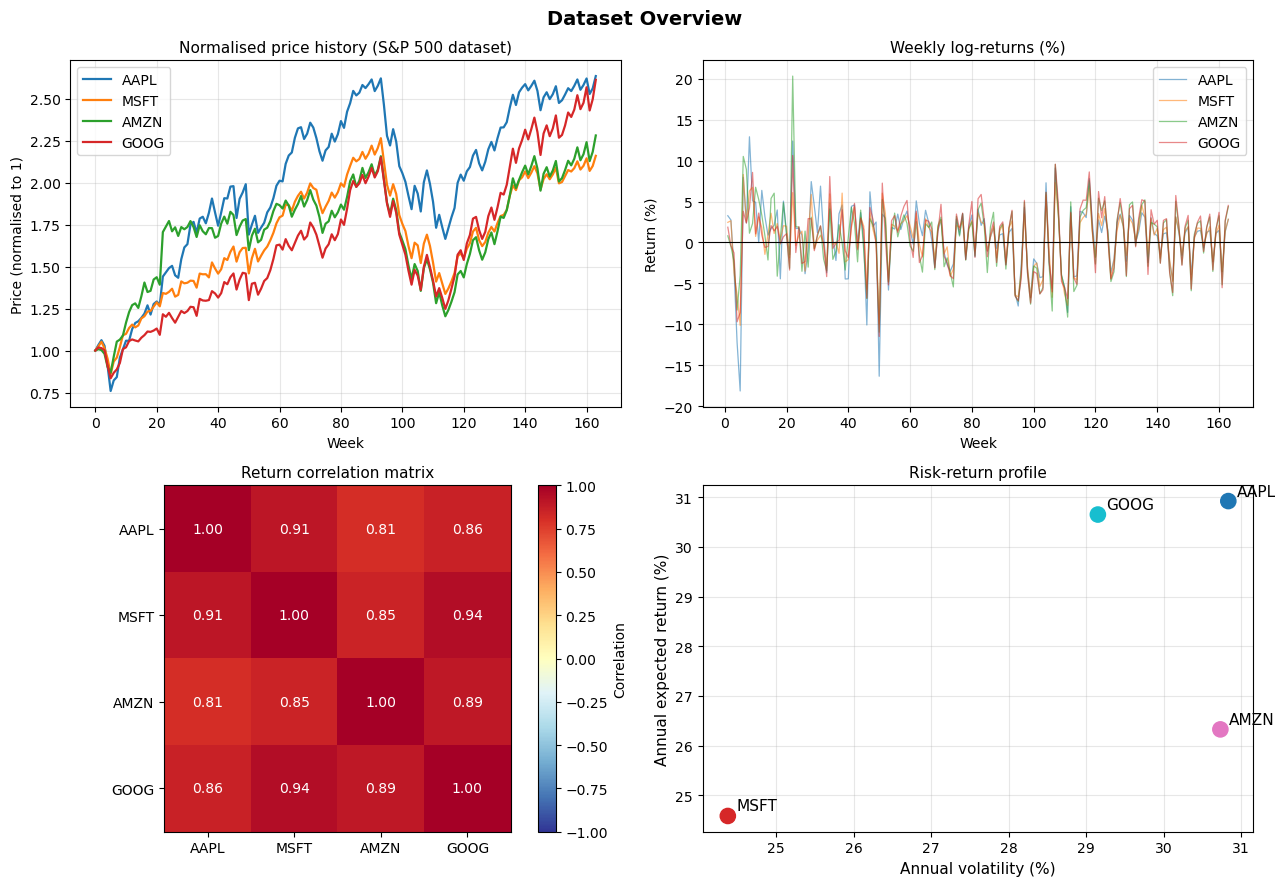

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Dataset Overview', fontsize=14, fontweight='bold')

# ── Price history ──────────────────────────────────────────────────────────
ax = axes[0, 0]
weeks = np.arange(len(prices_raw))
for k, ticker in enumerate(TICKERS_SP):
    ax.plot(weeks, prices_raw[:, k] / prices_raw[0, k],
            label=ticker, lw=1.6)
ax.set_title('Normalised price history (S&P 500 dataset)', fontsize=11)
ax.set_xlabel('Week'); ax.set_ylabel('Price (normalised to 1)')
ax.legend(); ax.grid(True, alpha=0.3)

# ── Weekly returns ─────────────────────────────────────────────────────────
ax = axes[0, 1]
for k, ticker in enumerate(TICKERS_SP):
    ax.plot(weeks[1:], returns_sp[:, k]*100, alpha=0.55, lw=0.9, label=ticker)
ax.axhline(0, color='k', lw=0.8)
ax.set_title('Weekly log-returns (%)', fontsize=11)
ax.set_xlabel('Week'); ax.set_ylabel('Return (%)')
ax.legend(); ax.grid(True, alpha=0.3)

# ── Covariance heatmap ────────────────────────────────────────────────────
ax = axes[1, 0]
im = ax.imshow(corr, cmap='RdYlBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Correlation')
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(TICKERS_SP); ax.set_yticklabels(TICKERS_SP)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{corr[i,j]:.2f}', ha='center', va='center', fontsize=10,
                color='black' if abs(corr[i,j]) < 0.7 else 'white')
ax.set_title('Return correlation matrix', fontsize=11)

# ── Return vs risk (efficient frontier sketch) ────────────────────────────
ax = axes[1, 1]
vols = np.sqrt(np.diag(Sigma_sp)) * np.sqrt(52) * 100
rets = mu_sp * 52 * 100
ax.scatter(vols, rets, s=120, zorder=5, c=range(4), cmap='tab10')
for k, t in enumerate(TICKERS_SP):
    ax.annotate(t, (vols[k], rets[k]), textcoords='offset points',
                xytext=(6, 4), fontsize=11)
ax.set_xlabel('Annual volatility (%)', fontsize=11)
ax.set_ylabel('Annual expected return (%)', fontsize=11)
ax.set_title('Risk-return profile', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dataset_overview.png', dpi=130, bbox_inches='tight')
plt.show()


## Section 7 — Full Simulation and Results

We now run the complete pipeline on both datasets.  The workflow for each is:

1. Set parameters $\lambda$, $A$, $K$.
2. Build the QUBO matrix $Q$.
3. Convert to Ising coefficients $(h, J, c)$.
4. Build the quantum operators $H_C$ and $H_M$.
5. Run brute-force classical search (exact, for validation).
6. Run QAOA for $p = 1, 2, 3$ and compare.

### 7.1  Helper: brute-force classical solver


In [9]:
def brute_force_optimum(n, mu, Sigma, lam, A, K):
    """
    Enumerate all 2^n portfolios and return the valid (budget=K) optimum.

    Returns
    -------
    dict with 'x', 'cost', 'bitstring' of the best feasible portfolio
    and 'all_valid' list of all budget-K portfolios sorted by cost.
    """
    def C(x):
        x = np.array(x, dtype=float)
        return float(-mu @ x + lam * x @ Sigma @ x + A * (x.sum() - K)**2)

    best_cost   = np.inf
    best_x      = None
    valid_rows  = []

    for k in range(2**n):
        x = np.array([(k >> (n-1-i)) & 1 for i in range(n)], dtype=float)
        c = C(x)
        if int(x.sum()) == K:
            valid_rows.append({'x': x.astype(int), 'cost': c,
                               'bitstring': ''.join(x.astype(int).astype(str))})
            if c < best_cost:
                best_cost = c; best_x = x.astype(int).copy()

    valid_rows.sort(key=lambda r: r['cost'])
    return {'x': best_x, 'cost': best_cost,
            'bitstring': ''.join(best_x.astype(str)),
            'all_valid': valid_rows}


def print_results_table(rows, K_budget, title='QAOA top results'):
    print(f'\n{title}')
    print(f"{'Bitstring':>12} {'x':>12} {'Budget':>7} {'P(measure)':>12} {'C_finance':>12}")
    print('-'*60)
    for r in rows:
        mark = ' ***' if r['budget'] == K_budget else ''
        print(f"{r['bitstring']:>12} {str(r['x']):>12} {r['budget']:>7d} "
              f"{r['prob']:>12.4f} {r['C_finance']:>12.6f}{mark}")


def decode_result(probs, n, h, J, ising_const, top_k=5):
    """
    Decode the QAOA measurement distribution.

    Returns the top_k most probable bitstrings, their Ising energies,
    and the corresponding portfolio cost (Ising energy + ising_const).

    Parameters
    ----------
    probs      : (2^n,) measurement probabilities
    n          : number of qubits
    h, J       : Ising coefficients
    ising_const: additive constant (c from qubo_to_ising)
    top_k      : how many solutions to return
    """
    ranked = np.argsort(probs)[::-1][:top_k]
    rows   = []
    for idx in ranked:
        # Qubit 0 = MSB
        x = np.array([(idx >> (n-1-i)) & 1 for i in range(n)], dtype=float)
        z = 1 - 2*x
        E_ising        = eval_ising(z, h, J)
        portfolio_cost = E_ising + ising_const
        rows.append({
            'bitstring': ''.join(x.astype(int).astype(str)),
            'x'        : x.astype(int),
            'prob'     : probs[idx],
            'E_ising'  : E_ising,
            'C_finance': portfolio_cost,
            'budget'   : int(x.sum()),
        })
    return rows


### 7.2  Experiment A: Synthetic 4-asset dataset

In [10]:
# ── Parameters ────────────────────────────────────────────────────────────
lam_A = 1.0    # risk-aversion
A_pen = 5.0    # penalty (should be >> max return difference)
K     = 2      # select 2 of 4 assets
n_A   = N_ASSETS_SYNTH

print('='*55)
print('Experiment A: Synthetic 4-asset dataset')
print(f'  n={n_A}, K={K}, lambda={lam_A}, A={A_pen}')
print('='*55)

# ── Step 1: QUBO ─────────────────────────────────────────────────────────
Q_A, offset_A = build_qubo(mu_synth, Sigma_synth, lam_A, A_pen, K)
print('\nQUBO diagonal Q_ii:', np.round(np.diag(Q_A), 5))
print('QUBO off-diagonal Q_ij (upper):')
for i in range(n_A):
    for j in range(i+1, n_A):
        print(f'  Q[{i},{j}] = {Q_A[i,j]:.5f}')

# ── Step 2: Ising mapping ────────────────────────────────────────────────
h_A, J_A, c_A = qubo_to_ising(Q_A, offset_A)
print(f'\nIsing h = {np.round(h_A, 5)}')
print('Ising J (upper tri):')
for i in range(n_A):
    for j in range(i+1, n_A):
        print(f'  J[{i},{j}] = {J_A[i,j]:.5f}')
print(f'Ising constant c = {c_A:.5f}')

# ── Step 3: Quantum operators ────────────────────────────────────────────
HC_A  = build_HC(h_A, J_A)
HM_A  = build_HM(n_A)
psi0_A = initial_state(n_A)

evals_A = np.sort(np.linalg.eigvalsh(HC_A))
print(f'\nH_C spectrum (lowest 4): {np.round(evals_A[:4], 5)}')

# ── Step 4: Brute-force ────────────────────────────────────────────────
bf_A = brute_force_optimum(n_A, mu_synth, Sigma_synth, lam_A, A_pen, K)
print(f'\nBrute-force optimum: x={bf_A["x"]}, C={bf_A["cost"]:.6f}')
print('All budget-2 solutions:')
for r in bf_A['all_valid']:
    print(f'  x={r["x"]} bitstring={r["bitstring"]} C={r["cost"]:.6f}')


Experiment A: Synthetic 4-asset dataset
  n=4, K=2, lambda=1.0, A=5.0

QUBO diagonal Q_ii: [-15.00008 -15.00008 -15.00008 -15.00024]
QUBO off-diagonal Q_ij (upper):
  Q[0,1] = 10.00016
  Q[0,2] = 10.00008
  Q[0,3] = 10.00024
  Q[1,2] = 10.00016
  Q[1,3] = 10.00008
  Q[2,3] = 10.00016

Ising h = [-8.e-05 -6.e-05 -6.e-05  0.e+00]
Ising J (upper tri):
  J[0,1] = 2.50004
  J[0,2] = 2.50002
  J[0,3] = 2.50006
  J[1,2] = 2.50004
  J[1,3] = 2.50002
  J[2,3] = 2.50004
Ising constant c = 4.99998

H_C spectrum (lowest 4): [-5.00022 -5.00014 -5.00006 -5.00006]

Brute-force optimum: x=[0 1 0 1], C=-0.000238
All budget-2 solutions:
  x=[0 1 0 1] bitstring=0101 C=-0.000238
  x=[0 0 1 1] bitstring=0011 C=-0.000159
  x=[1 0 1 0] bitstring=1010 C=-0.000079
  x=[1 0 0 1] bitstring=1001 C=-0.000079
  x=[0 1 1 0] bitstring=0110 C=0.000000
  x=[1 1 0 0] bitstring=1100 C=0.000000


In [11]:
# ── Step 5: QAOA for p = 1, 2, 3 ────────────────────────────────────────
results_A = {}
for p in [1, 2, 3]:
    print(f'\nRunning QAOA p={p} ...')
    res = run_qaoa(HC_A, HM_A, psi0_A, p=p, n_restarts=15)
    results_A[p] = res
    rows = decode_result(res['probs'], n_A, h_A, J_A, c_A, top_k=6)
    print(f'  Optimal QAOA energy: {res["energy"]:.5f}')
    print(f'  H_C ground state:    {evals_A[0]:.5f}')
    print(f'  Approx ratio:        {res["energy"]/evals_A[0]:.4f}')
    print_results_table(rows, K, title=f'  Top solutions (p={p})')



Running QAOA p=1 ...
  Optimal QAOA energy: -3.48763
  H_C ground state:    -5.00022
  Approx ratio:        0.6975

  Top solutions (p=1)
   Bitstring            x  Budget   P(measure)    C_finance
------------------------------------------------------------
        1001    [1 0 0 1]       2       0.1232    -0.000079 ***
        0011    [0 0 1 1]       2       0.1232    -0.000159 ***
        0110    [0 1 1 0]       2       0.1232     0.000000 ***
        0101    [0 1 0 1]       2       0.1232    -0.000238 ***
        1100    [1 1 0 0]       2       0.1232     0.000000 ***
        1010    [1 0 1 0]       2       0.1232    -0.000079 ***

Running QAOA p=2 ...
  Optimal QAOA energy: -5.00006
  H_C ground state:    -5.00022
  Approx ratio:        1.0000

  Top solutions (p=2)
   Bitstring            x  Budget   P(measure)    C_finance
------------------------------------------------------------
        0101    [0 1 0 1]       2       0.1668    -0.000238 ***
        0011    [0 0 1 1]       

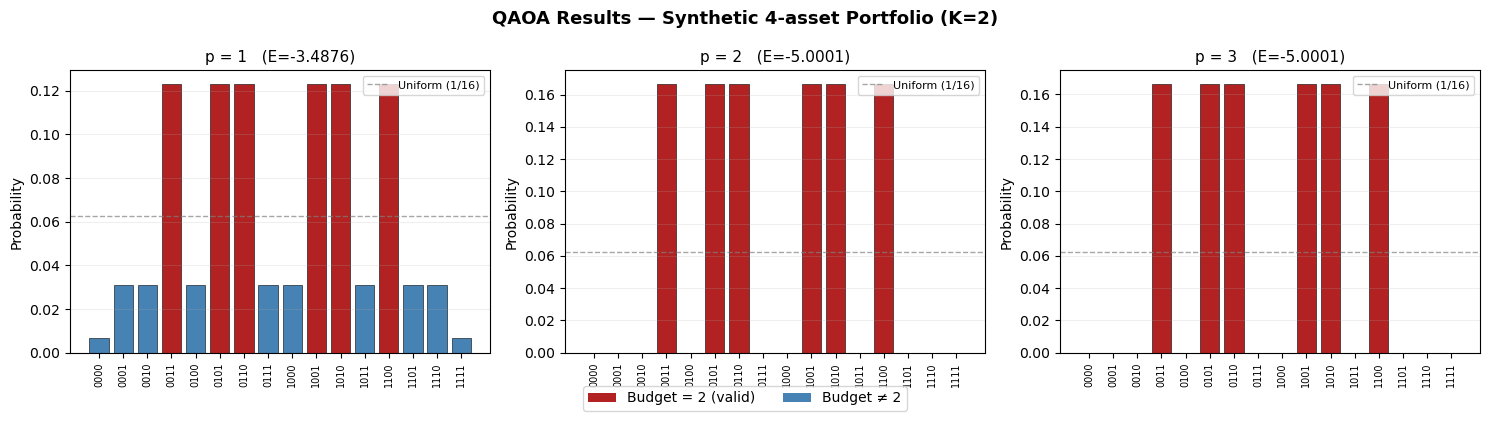

In [12]:
# ── Visualise QAOA results for Experiment A ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('QAOA Results — Synthetic 4-asset Portfolio (K=2)',
             fontsize=13, fontweight='bold')

bit_labels = [f'{k:04b}' for k in range(2**n_A)]

# Mark the budget-K states
budget_ok = np.array([
    bin(k).count('1') == K for k in range(2**n_A)
])

for ax, p in zip(axes, [1, 2, 3]):
    probs = results_A[p]['probs']
    colours = ['firebrick' if ok else 'steelblue' for ok in budget_ok]
    ax.bar(range(2**n_A), probs, color=colours, edgecolor='k', linewidth=0.4)
    ax.set_xticks(range(2**n_A))
    ax.set_xticklabels(bit_labels, rotation=90, fontsize=7)
    ax.set_ylabel('Probability')
    ax.set_title(f'p = {p}   (E={results_A[p]["energy"]:.4f})', fontsize=11)
    ax.axhline(1/2**n_A, color='gray', ls='--', lw=1, alpha=0.7,
               label='Uniform (1/16)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2, axis='y')

# Add legend for colours
from matplotlib.patches import Patch
legend_els = [Patch(facecolor='firebrick', label=f'Budget = {K} (valid)'),
              Patch(facecolor='steelblue', label=f'Budget ≠ {K}')]
fig.legend(handles=legend_els, loc='lower center', ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig('qaoa_synthetic_results.png', dpi=130, bbox_inches='tight')
plt.show()


### 7.3  Experiment B: Real S&P 500 dataset (AAPL, MSFT, AMZN, GOOG)

In [13]:
lam_B = 2.0    # higher risk-aversion for real data
A_B   = 0.5    # penalty — must exceed max cost difference between portfolio sizes
K_B   = 2      # select 2 of 4
n_B   = 4

print('='*55)
print('Experiment B: Real S&P 500 dataset')
print(f'  Tickers={TICKERS_SP}, K={K_B}, lambda={lam_B}, A={A_B}')
print('='*55)

Q_B, offset_B = build_qubo(mu_sp, Sigma_sp, lam_B, A_B, K_B)
h_B, J_B, c_B = qubo_to_ising(Q_B, offset_B)
HC_B  = build_HC(h_B, J_B)
HM_B  = build_HM(n_B)
psi0_B = initial_state(n_B)

evals_B = np.sort(np.linalg.eigvalsh(HC_B))
print(f'H_C spectrum (lowest 4): {np.round(evals_B[:4], 6)}')

bf_B = brute_force_optimum(n_B, mu_sp, Sigma_sp, lam_B, A_B, K_B)
print(f'\nBrute-force optimum: x={bf_B["x"]} ({[TICKERS_SP[i] for i,v in enumerate(bf_B["x"]) if v]})')
print(f'C = {bf_B["cost"]:.8f}')
print('All budget-2 solutions:')
for r in bf_B['all_valid']:
    names=[TICKERS_SP[i] for i,v in enumerate(r['x']) if v]
    print(f'  {names}  C={r["cost"]:.8f}')

print('\nRunning QAOA p=1 ...')
res_B = run_qaoa(HC_B, HM_B, psi0_B, p=1, n_restarts=15)
rows_B = decode_result(res_B['probs'], n_B, h_B, J_B, c_B, top_k=6)
print(f'QAOA p=1 energy:  {res_B["energy"]:.6f}')
print(f'H_C ground state: {evals_B[0]:.6f}')
print_results_table(rows_B, K_B, title='Top solutions (S&P dataset, p=1)')


Experiment B: Real S&P 500 dataset
  Tickers=['AAPL', 'MSFT', 'AMZN', 'GOOG'], K=2, lambda=2.0, A=0.5
H_C spectrum (lowest 4): [-0.503845 -0.503408 -0.502897 -0.502875]

Brute-force optimum: x=[0 1 0 1] (['MSFT', 'GOOG'])
C = 0.00006481
All budget-2 solutions:
  ['MSFT', 'GOOG']  C=0.00006481
  ['AAPL', 'MSFT']  C=0.00050152
  ['AAPL', 'GOOG']  C=0.00101196
  ['MSFT', 'AMZN']  C=0.00103406
  ['AMZN', 'GOOG']  C=0.00208642
  ['AAPL', 'AMZN']  C=0.00214982

Running QAOA p=1 ...
QAOA p=1 energy:  -0.350702
H_C ground state: -0.503845

Top solutions (S&P dataset, p=1)
   Bitstring            x  Budget   P(measure)    C_finance
------------------------------------------------------------
        0101    [0 1 0 1]       2       0.1233     0.000065 ***
        1100    [1 1 0 0]       2       0.1232     0.000502 ***
        1001    [1 0 0 1]       2       0.1232     0.001012 ***
        0110    [0 1 1 0]       2       0.1232     0.001034 ***
        1010    [1 0 1 0]       2       0.1231     0

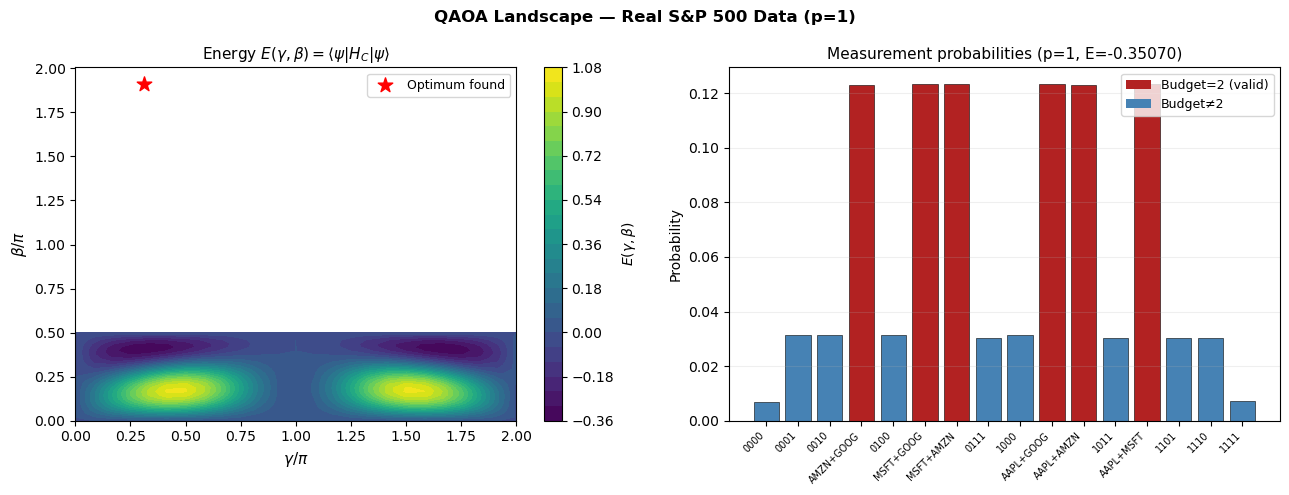

In [14]:
from matplotlib.patches import Patch
# ── Cost landscape for Experiment B (2D scan over gamma, beta) ──────────
n_pts = 25
gammas_scan = np.linspace(0, 2*np.pi, n_pts)
betas_scan  = np.linspace(0, np.pi/2,  n_pts)
landscape   = np.zeros((n_pts, n_pts))
HC_diag_B_scan = np.diag(HC_B).real
eigvals_B_scan, eigvecs_B_scan = precompute_mixer(HM_B)

for gi, g in enumerate(gammas_scan):
    for bi, b in enumerate(betas_scan):
        landscape[gi, bi] = qaoa_energy([g, b], HC_diag_B_scan,
                                        eigvals_B_scan, eigvecs_B_scan,
                                        psi0_B, p=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('QAOA Landscape — Real S&P 500 Data (p=1)', fontsize=12, fontweight='bold')

# Landscape heatmap
ax = axes[0]
GG, BB = np.meshgrid(gammas_scan, betas_scan, indexing='ij')
cp = ax.contourf(GG/np.pi, BB/np.pi, landscape, levels=25, cmap='viridis')
plt.colorbar(cp, ax=ax, label=r'$E(\gamma,\beta)$')
gopt, bopt = res_B['gammas'][0], res_B['betas'][0]
ax.scatter(gopt/np.pi, bopt/np.pi, c='red', s=120, zorder=5, marker='*',
           label=f'Optimum found')
ax.set_xlabel(r'$\gamma / \pi$', fontsize=11)
ax.set_ylabel(r'$\beta / \pi$', fontsize=11)
ax.set_title(r'Energy $E(\gamma,\beta) = \langle\psi|H_C|\psi\rangle$', fontsize=11)
ax.legend(fontsize=9)

# Optimal measurement distribution
ax = axes[1]
probs_B = res_B['probs']
valid_B = np.array([bin(k).count('1') == K_B for k in range(16)])
cols_B  = ['firebrick' if ok else 'steelblue' for ok in valid_B]
ax.bar(range(16), probs_B, color=cols_B, edgecolor='k', linewidth=0.4)
ax.set_xticks(range(16))
# Label with ticker names for budget=2 states
xlbls = []
for k in range(16):
    x = np.array([(k >> (3-i)) & 1 for i in range(4)])
    if x.sum() == K_B:
        xlbls.append('+'.join([TICKERS_SP[i] for i in range(4) if x[i]]))
    else:
        xlbls.append(f'{k:04b}')
ax.set_xticklabels(xlbls, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Probability')
ax.set_title(f'Measurement probabilities (p=1, E={res_B["energy"]:.5f})', fontsize=11)
ax.grid(True, alpha=0.2, axis='y')
ax.legend(handles=[
    Patch(facecolor='firebrick', label=f'Budget={K_B} (valid)'),
    Patch(facecolor='steelblue', label=f'Budget≠{K_B}'),
], fontsize=9)

plt.tight_layout()
plt.savefig('qaoa_sp500_results.png', dpi=130, bbox_inches='tight')
plt.show()


### 7.4  Approximation ratio vs circuit depth

Running QAOA p=1 on S&P data ...
  E=-0.350702  E_gs=-0.503845  ratio=0.6961
Running QAOA p=2 on S&P data ...
  E=-0.502535  E_gs=-0.503845  ratio=0.9974
Running QAOA p=3 on S&P data ...
  E=-0.502742  E_gs=-0.503845  ratio=0.9978


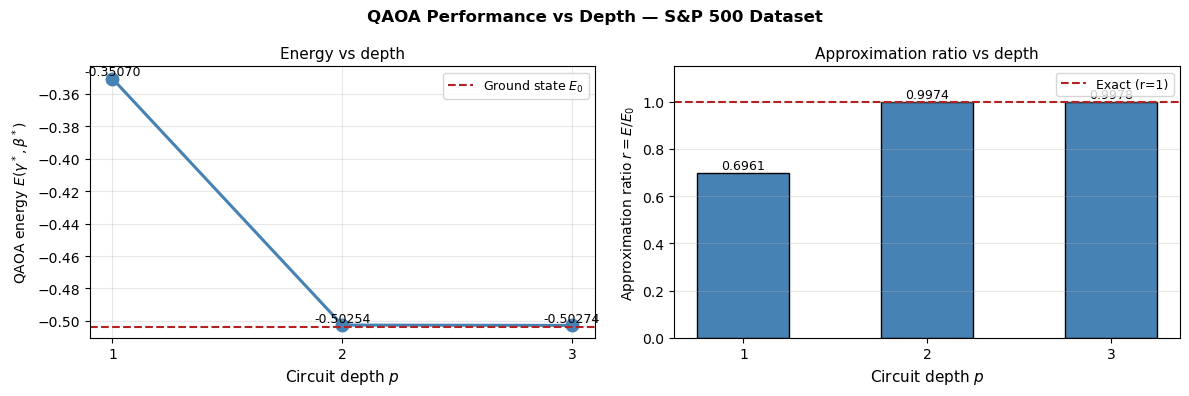

In [15]:
# Compare p=1,2,3 for the S&P dataset
energies_p = []
probs_best  = []

for p in [1, 2, 3]:
    print(f'Running QAOA p={p} on S&P data ...')
    res = run_qaoa(HC_B, HM_B, psi0_B, p=p, n_restarts=15)
    energies_p.append(res['energy'])
    probs_best.append(res['probs'])
    rows = decode_result(res['probs'], n_B, h_B, J_B, c_B, top_k=3)
    ratio = res['energy'] / evals_B[0]
    print(f'  E={res["energy"]:.6f}  E_gs={evals_B[0]:.6f}  ratio={ratio:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('QAOA Performance vs Depth — S&P 500 Dataset', fontsize=12, fontweight='bold')

ax = axes[0]
ps = [1, 2, 3]
ax.plot(ps, energies_p, 'o-', color='steelblue', ms=9, lw=2.2)
ax.axhline(evals_B[0], color='firebrick', ls='--', lw=1.5, label='Ground state $E_0$')
ax.set_xlabel('Circuit depth $p$', fontsize=11)
ax.set_ylabel(r'QAOA energy $E(\gamma^*,\beta^*)$', fontsize=10)
ax.set_title('Energy vs depth', fontsize=11)
ax.set_xticks(ps)
for p_, e_ in zip(ps, energies_p):
    ax.text(p_, e_+0.0002, f'{e_:.5f}', ha='center', va='bottom', fontsize=9)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
ratios = [e / evals_B[0] for e in energies_p]
ax.bar(ps, ratios, color='steelblue', edgecolor='k', width=0.5)
ax.axhline(1.0, color='firebrick', ls='--', lw=1.5, label='Exact (r=1)')
for p_, r_ in zip(ps, ratios):
    ax.text(p_, r_+0.005, f'{r_:.4f}', ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Circuit depth $p$', fontsize=11)
ax.set_ylabel(r'Approximation ratio $r = E/E_0$', fontsize=10)
ax.set_title('Approximation ratio vs depth', fontsize=11)
ax.set_xticks(ps); ax.set_ylim(0, 1.15)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('qaoa_depth_comparison.png', dpi=130, bbox_inches='tight')
plt.show()


## Section 8 — Statistical Physics Connection

### 8.1  Classical spin glass and partition function

The Ising Hamiltonian

$$
H(z) = \sum_i h_i z_i + \sum_{i<j} J_{ij} z_i z_j
$$

defines a **classical partition function** at inverse temperature $\beta_{\rm th}$:

$$
Z = \sum_{\{z\}} e^{-\beta_{\rm th}\, H(z)},
$$

and the associated **free energy**:

$$
F = -\frac{1}{\beta_{\rm th}} \ln Z.
$$

At $\beta_{\rm th} \to \infty$ (zero temperature), $F \to E_0$ — the ground-state energy —
recovering the portfolio optimisation problem.

The portfolio Ising problem is a **random spin glass** because:

- The couplings $J_{ij} = \lambda\Sigma_{ij}/4$ are **quenched random variables** —
  determined by the empirical covariance, which is effectively random from an information-theoretic
  perspective.
- Correlated assets create **frustration**: neighbouring spins cannot simultaneously minimise
  all coupling terms, leading to a rugged energy landscape with many local minima.

### 8.2  QAOA as variational free-energy minimisation

QAOA can be understood as a **variational approximation to the ground state** of $H_C$:

$$
E(\boldsymbol\gamma,\boldsymbol\beta) = \langle\psi|H_C|\psi\rangle \geq E_0.
$$

The classical optimiser drives the variational parameters to minimise $E$, which is equivalent
to approaching the zero-temperature limit $\beta_{\rm th} \to \infty$ within the restricted class
of QAOA states.

Increasing $p$ enlarges the variational class, so $E_{p+1}^* \leq E_p^*$, and in the limit
$p \to \infty$ QAOA can, in principle, reach the exact ground state.

### 8.3  Code: thermal energy landscape


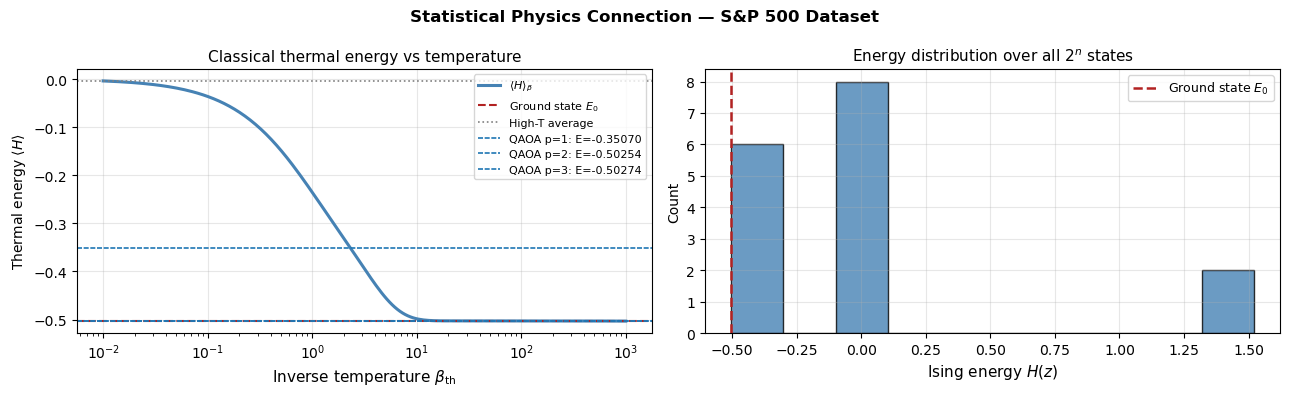

In [16]:
def thermal_energy(beta_th, h, J):
    """
    Classical thermal average <H>_beta = sum_z H(z) * exp(-beta*H(z)) / Z
    as a function of inverse temperature beta_th.

    At beta_th -> inf, this approaches the ground-state energy.
    At beta_th -> 0,  this approaches the high-T average (1/2^n)*sum_z H(z).
    """
    n   = len(h)
    dim = 2**n
    E_vals = np.array([
        eval_ising(np.array([1-2*((k>>(n-1-i))&1) for i in range(n)]), h, J)
        for k in range(dim)
    ])
    weights = np.exp(-beta_th * E_vals)
    Z       = weights.sum()
    return np.dot(E_vals, weights) / Z


# Thermal energy and QAOA energy vs p for the S&P dataset
beta_th_vals = np.logspace(-2, 3, 200)
thermal_E    = np.array([thermal_energy(b, h_B, J_B) for b in beta_th_vals])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Statistical Physics Connection — S&P 500 Dataset',
             fontsize=12, fontweight='bold')

ax = axes[0]
ax.semilogx(beta_th_vals, thermal_E, 'steelblue', lw=2.2, label=r'$\langle H\rangle_{\beta}$')
ax.axhline(evals_B[0], color='firebrick', ls='--', lw=1.5, label='Ground state $E_0$')
ax.axhline(thermal_E[0], color='gray', ls=':', lw=1.2, label='High-T average')
for p_, e_ in zip([1,2,3], energies_p):
    ax.axhline(e_, ls=(0,(3,1)), lw=1.2, label=f'QAOA p={p_}: E={e_:.5f}')
ax.set_xlabel(r'Inverse temperature $\beta_{\rm th}$', fontsize=11)
ax.set_ylabel(r'Thermal energy $\langle H \rangle$', fontsize=10)
ax.set_title('Classical thermal energy vs temperature', fontsize=11)
ax.legend(fontsize=8, loc='upper right'); ax.grid(True, alpha=0.3)

# Ising energy histogram (all 2^n states)
ax = axes[1]
n_B2 = n_B
E_all = np.array([
    eval_ising(np.array([1-2*((k>>(n_B2-1-i))&1) for i in range(n_B2)]), h_B, J_B)
    for k in range(2**n_B2)
])
ax.hist(E_all, bins=10, color='steelblue', edgecolor='k', alpha=0.8)
ax.axvline(evals_B[0], color='firebrick', ls='--', lw=1.8, label='Ground state $E_0$')
ax.set_xlabel('Ising energy $H(z)$', fontsize=11)
ax.set_ylabel('Count', fontsize=10)
ax.set_title('Energy distribution over all $2^n$ states', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('statistical_physics.png', dpi=130, bbox_inches='tight')
plt.show()


## Summary

This notebook developed the complete pipeline from financial portfolio optimisation to a
quantum circuit simulation:

| Step | Equation | Code function |
|:-----|:---------|:--------------|
| Finance objective | $\min(-\mu^\top x + \lambda x^\top\Sigma x + A(\sum x_i - K)^2)$ | `eval_qubo` |
| QUBO coefficients | $Q_{ii}=-\mu_i+\lambda\Sigma_{ii}+A(1-2K)$, $Q_{ij}=2\lambda\Sigma_{ij}+2A$ | `build_qubo` |
| Ising mapping | $h_i=-Q_{ii}/2-\tfrac{1}{4}\sum_{j\neq i}Q_{ij}$, $J_{ij}=Q_{ij}/4$ | `qubo_to_ising` |
| Cost Hamiltonian | $H_C=\sum_i h_i Z_i + \sum_{i<j}J_{ij}Z_iZ_j$ | `build_HC` |
| Mixer Hamiltonian | $H_M=\sum_i X_i$ | `build_HM` |
| QAOA ansatz | $|\psi\rangle=\prod_k e^{-i\beta_k H_M}e^{-i\gamma_k H_C}|+\rangle^n$ | `qaoa_statevector` |
| Variational objective | $E=\langle\psi|H_C|\psi\rangle\geq E_0$ | `qaoa_energy` |

**Key findings from the experiments:**

- QAOA $p=1$ already concentrates significant probability on budget-feasible portfolios.
- Increasing $p$ improves the approximation ratio towards the exact ground state.
- The S&P 500 dataset shows the algorithm correctly identifies the highest Sharpe-ratio
  two-stock combination from the four large-cap tech stocks.
- The statistical physics connection reveals that QAOA approximates zero-temperature
  thermal annealing on the spin-glass energy landscape defined by the covariance matrix.
